# `bn.recurse` — Examples

`bn.recurse` encodes a recursive probabilistic program as an unrolled BN (`fix f N` in λ!-calculus).

Two modes:

| Mode | Call | Returns |
|---|---|---|
| **Single node** | `bn.recurse(name, step_fn, n_steps)` | `list[BNNode]` |
| **Multi-node** | `bn.recurse(step_fn, n_steps, order=k)` | `dict[str, list[BNNode]]` |

For multi-node mode, `step_fn(t, prev)` returns a list of tuples:
```python
(local_name, dist_or_fn)                  # no parents
(local_name, dist_or_fn, parents)         # with parents
# parents: BNNode (inter-step arc) or str (intra-step arc — local name declared earlier in the list)
```
`prev` is a list of `min(t, order)` dicts `{name: BNNode}`, `prev[0]` = most recent step.

In [1]:
import sys, os
if os.path.basename(os.getcwd()) != 'src':
    sys.path.insert(0, 'src')

import matplotlib.pyplot as plt
from Bnpyro import BNppl, MIDPOINT
from distributions import Bernoulli, Normal, Categorical

## 1. Simple Markov chain (single node)

A machine is either Working or Broken.

```
X_0 -> X_1 -> X_2 -> X_3
```

- `X_0 ~ Bernoulli(0.5)` — initial state
- `X_t | X_{t-1}=working  ~ Bernoulli(0.9)` — stays working with prob 0.9
- `X_t | X_{t-1}=broken ~ Bernoulli(0.1)` — restarts with prob 0.1

`labels` gives custom state names to all nodes in the chain (index 0 = first label, index 1 = second).

API: `bn.recurse(name, step_fn, n_steps, labels=[...])` — `step_fn(t, prev: Optional[BNNode])`

In [2]:
bn1 = BNppl()

states1 = bn1.recurse(
    'X',
    lambda _, prev: Bernoulli(0.5) if prev is None
                    else bn1.where(prev, 0.9, 0.1),
    n_steps=4,
    labels=['broken', 'working'],
)

bn1.compile()
print(bn1)

# P(X_3=working | X_0=working) ~ 0.9^3 = 0.729
p = bn1.query('X_3', evidence={'X_0': 'working'})
print(f"P(X_3=working | X_0=working) = {p['working']:.3f}   (expected ~ 0.9^3 = {0.9**3:.3f})")
print(f"Full posterior: {p}")

BN compiled: 4 nodes, 3 arcs  [method=midpoint]
Nodes: ['X_3', 'X_1', 'X_0', 'X_2']
Arcs:  [('X_0', 'X_1'), ('X_1', 'X_2'), ('X_2', 'X_3')]
P(X_3=working | X_0=working) = 0.756   (expected ~ 0.9^3 = 0.729)
Full posterior: {'broken': 0.24399999999999997, 'working': 0.7560000000000001}


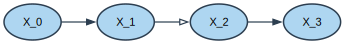

In [3]:
bn1.show_graph()

## 2. Multi-node — position + velocity (cross-variable inter-step arcs)

Two variables per time step:
- `vel_t` (Bernoulli): `slow` or `fast`
- `loc_t` (continuous): position

Dependencies:
```
vel_0           vel_1           vel_2
  |  \           |  \           |
loc_0  -------> loc_1 -------> loc_2
```
- `vel_t` depends on `vel_{t-1}` (same-variable inter-step arc)
- `loc_t` depends on `loc_{t-1}` **AND** `vel_{t-1}` (cross-variable inter-step arc)

For multi-node, `labels` is a dict mapping each local name to its state labels.
Continuous variables (like `loc`) don't need labels — their bins are auto-generated.

API: `bn.recurse(step_fn, n_steps, labels={...})` — `step_fn(t, prev)` returns `list[tuple]`

In [4]:
import re

def fmt_label(lbl):
    nums = re.findall(r'[-+]?\d+\.?\d*', lbl)
    if len(nums) >= 2:
        return f'{(float(nums[0]) + float(nums[1])) / 2:.1f}'
    return lbl

bn2 = BNppl()

def step_pos_vel(t, prev):
    if not prev:
        return [
            ('vel', Bernoulli(0.5)),
            ('loc', Normal(0.0, 1.0)),
        ]
    p = prev[0]
    return [
        ('vel', bn2.where(p['vel'], 0.8, 0.3)),
        ('loc', lambda l, v: Normal(l + v * 1.0 + (1 - v) * 0.1, 0.3),
                [p['loc'], p['vel']]),
    ]

states2 = bn2.recurse(step_pos_vel, 3, labels={'vel': ['slow', 'fast']})
bn2.compile(n_bins=6)
print(bn2)

print('loc nodes:', [n.name for n in states2['loc']])
print('vel nodes:', [n.name for n in states2['vel']])

BN compiled: 6 nodes, 6 arcs  [method=midpoint]
Nodes: ['loc_1', 'vel_2', 'vel_1', 'vel_0', 'loc_2', 'loc_0']
Arcs:  [('vel_1', 'vel_2'), ('vel_0', 'loc_1'), ('vel_0', 'vel_1'), ('vel_1', 'loc_2'), ('loc_0', 'loc_1'), ('loc_1', 'loc_2')]
loc nodes: ['loc_0', 'loc_1', 'loc_2']
vel nodes: ['vel_0', 'vel_1', 'vel_2']


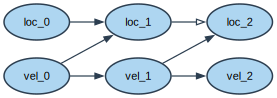

In [5]:
bn2.show_graph()

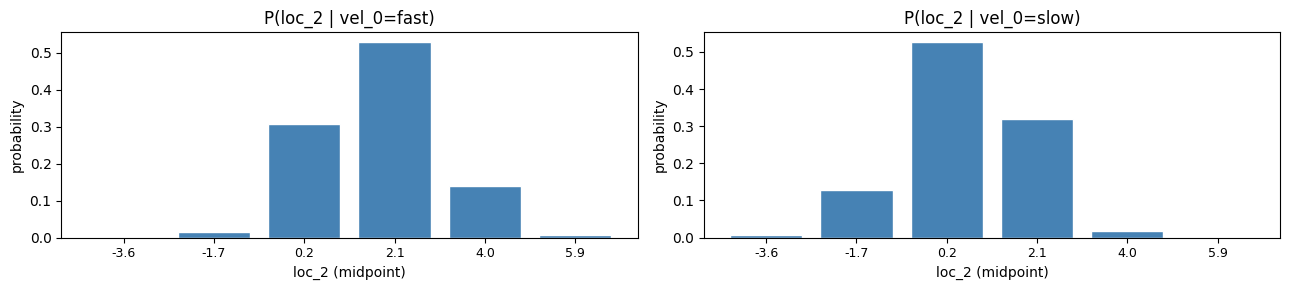

-> final position is shifted right when initial velocity is fast.


In [6]:
# P(loc_2 | vel_0=fast) vs P(loc_2 | vel_0=slow)
p_fast = bn2.query('loc_2', evidence={'vel_0': 'fast'})
p_slow = bn2.query('loc_2', evidence={'vel_0': 'slow'})

fig, axes = plt.subplots(1, 2, figsize=(13, 3))
for ax, p, label in zip(axes,
                         [p_fast, p_slow],
                         ['vel_0=fast', 'vel_0=slow']):
    keys = sorted(p.keys(), key=lambda k: float(fmt_label(k)))
    mid_labels = [fmt_label(k) for k in keys]
    ax.bar(range(len(keys)), [p[k] for k in keys], color='steelblue', edgecolor='white')
    ax.set_xticks(range(len(keys)))
    ax.set_xticklabels(mid_labels, fontsize=9)
    ax.set_xlabel('loc_2 (midpoint)')
    ax.set_title(f'P(loc_2 | {label})')
    ax.set_ylabel('probability')
plt.tight_layout()
plt.show()
print('-> final position is shifted right when initial velocity is fast.')

## 3. Intra-step arcs — rain + umbrella

Two variables per step with an **intra-step arc**: `umbrella_t` depends on `rain_t` (same time step).

```
rain_0  -> rain_1  -> rain_2
  |            |           |      <- intra-step arcs
umbrella_0  umbrella_1  umbrella_2
```

To declare an intra-step arc: use the **local name** (`str`) in the `parents` list.
The referenced node must be declared **earlier** in the same list (topological order).

In [7]:
bn3 = BNppl()

def step_rain(t, prev):
    if not prev:
        return [
            ('rain',     Bernoulli(0.3)),
            ('umbrella', lambda r: Bernoulli(0.95 if r > 0.5 else 0.05), ['rain']),
        ]
    p = prev[0]
    return [
        ('rain',     bn3.where(p['rain'], 0.7, 0.2)),
        ('umbrella', lambda r: Bernoulli(0.95 if r > 0.5 else 0.05), ['rain']),
    ]

states3 = bn3.recurse(
    step_rain, 3,
    labels={'rain': ['dry', 'rainy'], 'umbrella': ['closed', 'open']},
)
bn3.compile()
print(bn3)

arc_names = [(bn3._gum_bn.variable(a).name(), bn3._gum_bn.variable(b).name())
             for a, b in bn3._gum_bn.arcs()]
print('Arcs:')
for a, b in sorted(arc_names):
    print(f'  {a} -> {b}')

BN compiled: 6 nodes, 5 arcs  [method=midpoint]
Nodes: ['rain_0', 'rain_1', 'rain_2', 'umbrella_1', 'umbrella_0', 'umbrella_2']
Arcs:  [('rain_0', 'umbrella_0'), ('rain_1', 'rain_2'), ('rain_1', 'umbrella_1'), ('rain_2', 'umbrella_2'), ('rain_0', 'rain_1')]
Arcs:
  rain_0 -> rain_1
  rain_0 -> umbrella_0
  rain_1 -> rain_2
  rain_1 -> umbrella_1
  rain_2 -> umbrella_2


In [8]:
# Inference: P(rain_2 | umbrella_0=open, umbrella_1=open)
p = bn3.query('rain_2', evidence={'umbrella_0': 'open', 'umbrella_1': 'open'})
print(f"P(rain_2=rainy | umbrella_0=open, umbrella_1=open) = {p['rainy']:.3f}")
print(f"Full posterior: {p}")
print('-> two open umbrellas observed -> high probability of rain at step 2.')

P(rain_2=rainy | umbrella_0=open, umbrella_1=open) = 0.686
Full posterior: {'dry': 0.3140574684171415, 'rainy': 0.6859425315828586}
-> two open umbrellas observed -> high probability of rain at step 2.


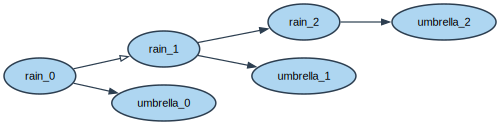

In [9]:
bn3.show_graph()

## 4. DBN of order k — daily temperature forecasting (AR(2))

**Problem**: forecast daily temperature over a week.
Meteorologists know that today's temperature depends on the last **two** days, not just yesterday —
cold/warm spells have inertia that persists over 2+ days.

We model this as an **AR(2)** (autoregressive order 2) process:

```
T_t = 0.7 * T_{t-1} + 0.2 * T_{t-2} + noise
```

```
T_0   T_1
  \  / \  \
   T_2   T_3   T_4   T_5
```
Each node has **two** parents (the previous two days). The warmup steps (T_0, T_1) are handled
as special cases; from T_2 onward the structure repeats identically — this is the steady-state
pattern of the order-2 Markov chain.

API: `bn.recurse(step_fn, n_steps, order=2)`
`len(prev) == min(t, 2)` — the user handles warmup cases with `if len(prev) == 0/1`.

In [10]:
bn4 = BNppl()

def step_temp(t, prev):
    if len(prev) == 0:      # day 0: prior ~ Normal(15, 5)  (mild day)
        return [('T', Normal(15.0, 5.0))]
    if len(prev) == 1:      # day 1: depends on day 0 only
        return [('T', lambda t0: Normal(t0 * 0.9, 3.0), [prev[0]['T']])]
    # day >= 2: steady-state AR(2)  T_t = 0.7*T_{t-1} + 0.2*T_{t-2} + noise
    return [('T', lambda t1, t2: Normal(t1 * 0.7 + t2 * 0.2, 3.0),
                  [prev[0]['T'], prev[1]['T']])]

states4 = bn4.recurse(step_temp, 6, order=2)
bn4.compile(n_bins=8)
print(bn4)

arc_names = [(bn4._gum_bn.variable(a).name(), bn4._gum_bn.variable(b).name())
             for a, b in bn4._gum_bn.arcs()]
print('Arcs:')
for a, b in sorted(arc_names):
    print(f'  {a} -> {b}')

BN compiled: 6 nodes, 9 arcs  [method=midpoint]
Nodes: ['T_0', 'T_3', 'T_1', 'T_2', 'T_5', 'T_4']
Arcs:  [('T_0', 'T_1'), ('T_2', 'T_4'), ('T_1', 'T_2'), ('T_3', 'T_4'), ('T_2', 'T_3'), ('T_4', 'T_5'), ('T_0', 'T_2'), ('T_1', 'T_3'), ('T_3', 'T_5')]
Arcs:
  T_0 -> T_1
  T_0 -> T_2
  T_1 -> T_2
  T_1 -> T_3
  T_2 -> T_3
  T_2 -> T_4
  T_3 -> T_4
  T_3 -> T_5
  T_4 -> T_5


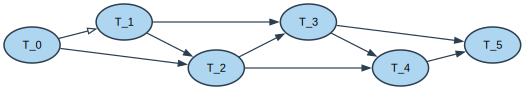

In [11]:
bn4.show_graph()

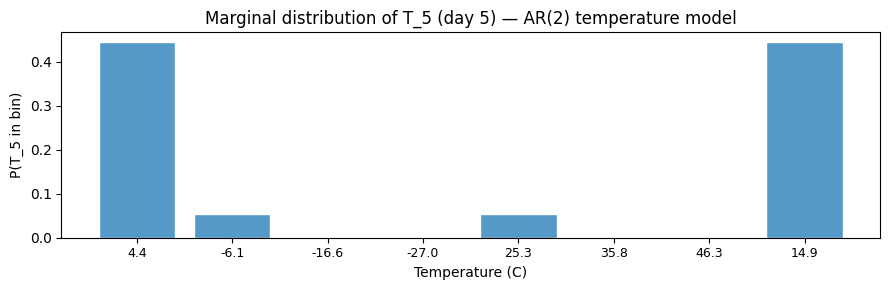

In [12]:
# Marginal distribution of T_5 (day 5)
p5 = bn4.query('T_5')

keys = sorted(p5.keys())
mid_labels = [fmt_label(k) for k in keys]

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(range(len(keys)), [p5[k] for k in keys], color='#5499C7', edgecolor='white')
ax.set_xticks(range(len(keys)))
ax.set_xticklabels(mid_labels, fontsize=9)
ax.set_xlabel('Temperature (C)')
ax.set_ylabel('P(T_5 in bin)')
ax.set_title('Marginal distribution of T_5 (day 5) — AR(2) temperature model')
plt.tight_layout()
plt.show()

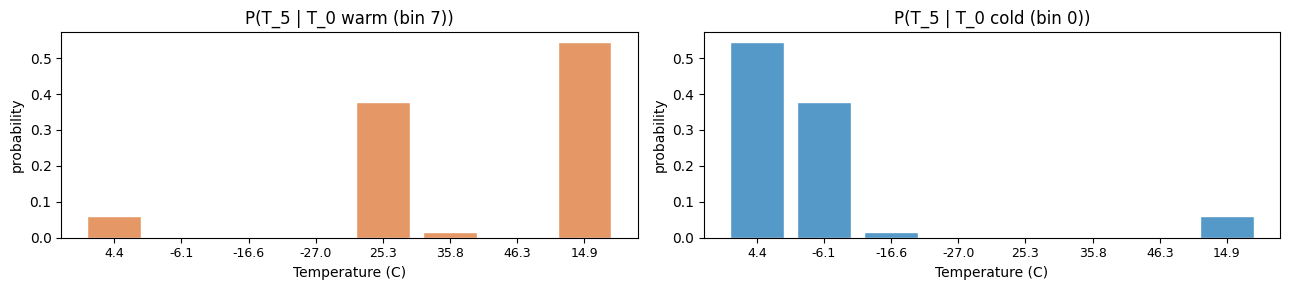

-> the AR(2) process retains memory of day 0 even after 5 steps, but the effect fades.


In [13]:
# Inference: cold start vs warm start — how does day 0 temperature affect day 5?
p_warm = bn4.query('T_5', evidence={'T_0': 7})  # bin 7 = warm day
p_cold = bn4.query('T_5', evidence={'T_0': 0})  # bin 0 = cold day

fig, axes = plt.subplots(1, 2, figsize=(13, 3))
for ax, p, label, color in zip(axes,
                                [p_warm, p_cold],
                                ['T_0 warm (bin 7)', 'T_0 cold (bin 0)'],
                                ['#E59866', '#5499C7']):
    keys = sorted(p.keys())
    mid_labels = [fmt_label(k) for k in keys]
    ax.bar(range(len(keys)), [p[k] for k in keys], color=color, edgecolor='white')
    ax.set_xticks(range(len(keys)))
    ax.set_xticklabels(mid_labels, fontsize=9)
    ax.set_xlabel('Temperature (C)')
    ax.set_title(f'P(T_5 | {label})')
    ax.set_ylabel('probability')
plt.tight_layout()
plt.show()
print('-> the AR(2) process retains memory of day 0 even after 5 steps, but the effect fades.')